In [19]:
%load_ext autoreload
%autoreload 2

import os
import pickle
import prince
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from matplotlib.collections import LineCollection
from matplotlib.font_manager import FontProperties
from scipy.stats import chi2_contingency
from sklearn.manifold import TSNE
import umap

# 獲取當前工作目錄
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
version3_path = os.path.join(parent_dir, "Version3")

# 暫時將工作目錄切換到 Version3（資料與前處理程式碼皆存放於此）
os.chdir(version3_path)

from utils.preprocess import preprocess, process_other

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'Heiti TC']
plt.rcParams['axes.unicode_minus'] = False

dataA2 = pd.read_csv("./Data/A2.csv", low_memory=False)
dataA1 = pd.read_csv("./Data/A1.csv")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
select_lst = [
    # 月份是為了篩選每個月2萬筆
    '發生月份',

    '天候名稱', '光線名稱', 
    '道路類別-第1當事者-名稱', '速限-第1當事者', 
    '路面狀況-路面鋪裝名稱', '路面狀況-路面狀態名稱', '路面狀況-路面缺陷名稱',
    '道路障礙-障礙物名稱', '道路障礙-視距品質名稱', '道路障礙-視距名稱',
    '號誌-號誌種類名稱', '號誌-號誌動作名稱',
    '車道劃分設施-分道設施-快車道或一般車道間名稱', '車道劃分設施-分道設施-快慢車道間名稱', '車道劃分設施-分道設施-路面邊線名稱',
    '當事者屬-性-別名稱', '當事者事故發生時年齡',
    '保護裝備名稱', '行動電話或電腦或其他相類功能裝置名稱',
    '肇事逃逸類別名稱-是否肇逃',
    '死亡受傷人數',

    # 大類別
    '道路型態大類別名稱', '事故位置大類別名稱',
    '車道劃分設施-分向設施大類別名稱',
    '事故類型及型態大類別名稱', '當事者區分-類別-大類別名稱-車種', '當事者行動狀態大類別名稱',
    '車輛撞擊部位大類別名稱-最初', '車輛撞擊部位大類別名稱-其他',

    # 兩個欄位只有兩個觀察值不同
    '肇因研判大類別名稱-主要',
    # '肇因研判大類別名稱-個別',
    
    # 子類別
    '道路型態子類別名稱', '事故位置子類別名稱', '事故類型及型態子類別名稱', '肇因研判子類別名稱-主要',
    '當事者區分-類別-子類別名稱-車種', '當事者行動狀態子類別名稱', '車輛撞擊部位子類別名稱-最初',
    '車輛撞擊部位子類別名稱-其他', '肇因研判子類別名稱-個別',
]

In [3]:
full_dataA1 = preprocess(dataA1, target='行人', lst=select_lst)
full_dataA2 = preprocess(dataA2, target='行人', lst=select_lst)
mapper_numpy, rbind_data, dummy_data, death, injuried, date_info = process_other(full_dataA1, full_dataA2, downsample=False, en=True, return_time=True)

['行動電話或電腦或其他相類功能裝置名稱', '當事者區分-類別-大類別名稱-車種', '車輛撞擊部位大類別名稱-最初']
dummy_data: (3143, 210)


# MCA

          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              0.157         3.15%                      3.15%
1              0.132         2.63%                      5.78%
2              0.113         2.25%                      8.04%
3              0.103         2.05%                     10.09%
4              0.093         1.86%                     11.95%
5              0.087         1.74%                     13.68%
6              0.085         1.69%                     15.38%
7              0.081         1.62%                     17.00%
8              0.080         1.60%                     18.60%
9              0.076         1.52%                     20.12%
10             0.069         1.37%                     21.49%
11             0.068         1.37%                     22.86%


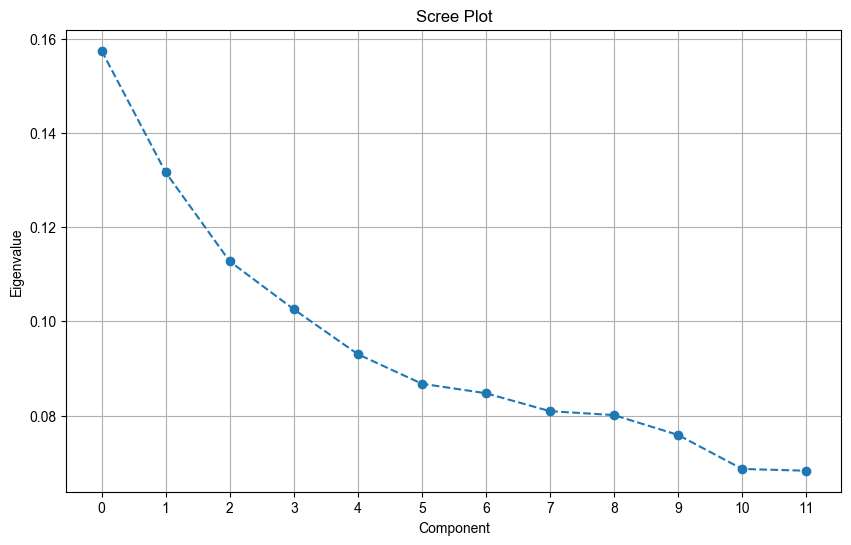

In [4]:
mca = prince.MCA(
    one_hot=False,
    n_components=12,
    n_iter=30,
    copy=True,
    check_input=True,
    random_state=42
)

mca.fit(dummy_data)
lens = mca.transform(dummy_data)

print(mca.eigenvalues_summary)

eigenvalues = mca.eigenvalues_

components = range(0, len(eigenvalues))

variance = mca.eigenvalues_summary['% of variance']

plt.figure(figsize=(10, 6))
plt.plot(components, eigenvalues, marker='o', linestyle='--')
plt.title("Scree Plot")
plt.xlabel("Component")
plt.ylabel("Eigenvalue")
plt.xticks(components)
plt.grid(True)
plt.show()

In [5]:
grid_search_info = {
    'lens': lens,
    'mapper_numpy': mapper_numpy,
    'rbind_data': rbind_data,
}
with open('../ForMatrix/CalculatedData/Pass.pkl', 'wb') as f:
    pickle.dump(grid_search_info, f)

# Helper functions for consistent coloring

These replicate `MapperPlotter`'s tab20 palette, frequency-threshold grouping, grey default, and `Line2D` legend, so the t-SNE/UMAP scatter plots below are visually and methodologically comparable to the existing Mapper figures.

In [20]:
def build_color_mapping(labels, threshold):
    """Same scheme as MapperPlotter.map_colors: tab20 palette for categories
    above the frequency threshold, grey (0.5, 0.5, 0.5, 1) for everything else."""
    counts = labels.value_counts()
    frequent = counts[counts > threshold].index.tolist()
    cmap = cm.get_cmap('tab20', max(len(frequent), 1))
    color_map = {cat: cmap(i) for i, cat in enumerate(frequent)}
    default_color = (0.5, 0.5, 0.5, 1)
    colors = labels.map(lambda v: color_map.get(v, default_color))
    return colors, color_map, default_color


def plot_embedding_pair(tsne_xy, umap_xy, choose, rbind_data, graph=None, threshold=500, size=8, anchor=1.0,
                         edge_alpha=0.15, edge_color='gray', edge_linewidth=0.3):
    """Same as before, with an optional overlay of a shared nearest-neighbor graph
    (pass e.g. reducer.graph_ from the UMAP fit above) so edges connecting visually
    separate regions of either embedding become visible on top of the colored scatter.
    `graph` should be a sparse (n_samples, n_samples) adjacency/affinity matrix."""
    labels = rbind_data[choose]
    colors, color_map, default_color = build_color_mapping(labels, threshold)

    edge_index = None
    if graph is not None:
        coo = graph.tocoo()
        edge_index = np.column_stack([coo.row, coo.col])

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    for ax, xy, title in zip(axes, [tsne_xy, umap_xy], ['t-SNE', 'UMAP']):
        if edge_index is not None:
            segments = np.stack([xy[edge_index[:, 0]], xy[edge_index[:, 1]]], axis=1)
            lc = LineCollection(segments, colors=edge_color, linewidths=edge_linewidth, alpha=edge_alpha, zorder=1)
            ax.add_collection(lc)
        ax.scatter(xy[:, 0], xy[:, 1], c=list(colors), s=size, alpha=0.8, zorder=2)
        ax.set_title(f'{title} — {choose}')
        ax.set_xlabel(f'{title} 1')
        ax.set_ylabel(f'{title} 2')

    handles = [Line2D([0], [0], marker='o', color='w', label=str(cat),
                       markerfacecolor=color, markersize=8)
               for cat, color in color_map.items()]
    handles.append(Line2D([0], [0], marker='o', color='w', label='Other',
                           markerfacecolor=default_color, markersize=8))
    fig.legend(handles=handles, loc='center left', bbox_to_anchor=(anchor, 0.5),
               framealpha=0.1, title=choose)
    plt.tight_layout()
    plt.show()


def plot_embedding_pair_rate(tsne_xy, umap_xy, choose, rbind_data, rate_col='死亡',
                              color_vmax=None, color_percentile=95, size=8):
    """Continuous coloring by the group-level rate of `rate_col`, mirroring
    MapperPlotter.plot(..., group_rate_col=...)."""
    labels = rbind_data[choose]
    group_rate = labels.map(rbind_data.groupby(choose)[rate_col].mean())

    vmax = color_vmax if color_vmax is not None else np.percentile(group_rate, color_percentile)
    norm = Normalize(vmin=group_rate.min(), vmax=vmax)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    scs = []
    for ax, xy, title in zip(axes, [tsne_xy, umap_xy], ['t-SNE', 'UMAP']):
        sc = ax.scatter(xy[:, 0], xy[:, 1], c=group_rate, cmap='jet', norm=norm, s=size, alpha=0.8)
        scs.append(sc)
        ax.set_title(f'{title} — {choose} (colored by {rate_col} rate)')
        ax.set_xlabel(f'{title} 1')
        ax.set_ylabel(f'{title} 2')

    cbar = fig.colorbar(scs[-1], ax=axes, extend='max', shrink=0.8)
    cbar.set_label(f'{rate_col} rate')
    plt.show()

# Current Visualization Methods Used (t-SNE / UMAP, replacing Mapper)

Both embeddings are fit directly on `mapper_numpy` — the exact one-hot numeric matrix Mapper itself clusters on — so this is a fair, same-input-representation visualization comparison, not a comparison against a classifier.

In [7]:
X = np.asarray(mapper_numpy, dtype=float)

tsne = TSNE(n_components=2, perplexity=30, init='pca', random_state=42, n_jobs=10)
tsne_xy = tsne.fit_transform(X)

reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42, n_jobs=10)
umap_xy = reducer.fit_transform(X)

/Users/wangqiqian/opt/anaconda3/envs/TrafficTDApython/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [8]:
embedding_path = './Data/TSNE_UMAP/pass_tsne_umap.pkl'
os.makedirs(os.path.dirname(embedding_path), exist_ok=True)
with open(embedding_path, 'wb') as f:
    pickle.dump({'tsne_xy': tsne_xy, 'umap_xy': umap_xy}, f)

# with open(embedding_path, 'rb') as f:
#     _emb = pickle.load(f)
#     tsne_xy, umap_xy = _emb['tsne_xy'], _emb['umap_xy']

# Significant Features (categorical coloring)

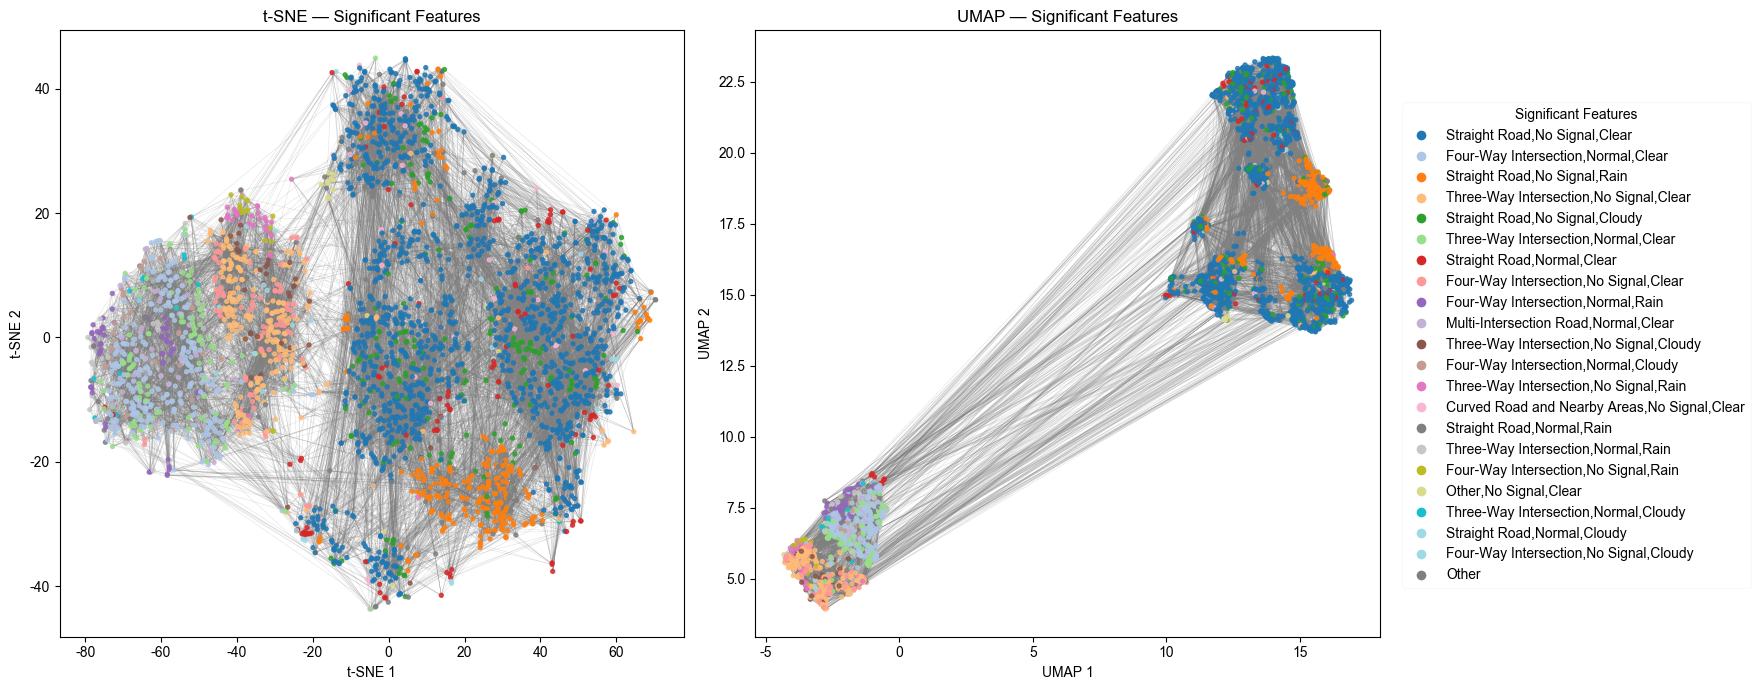

In [21]:
choose = 'Significant Features'
rbind_data['Significant Features'] = rbind_data['Road Category - Subcategory'] + ',' + rbind_data['Traffic Signal - Signal Operation'] + ',' + rbind_data["Weather Condition"]

plot_embedding_pair(tsne_xy, umap_xy, choose, rbind_data, graph=reducer.graph_, threshold=10, size=8, anchor=1)

# Significant Features — Fatality-Rate Coloring

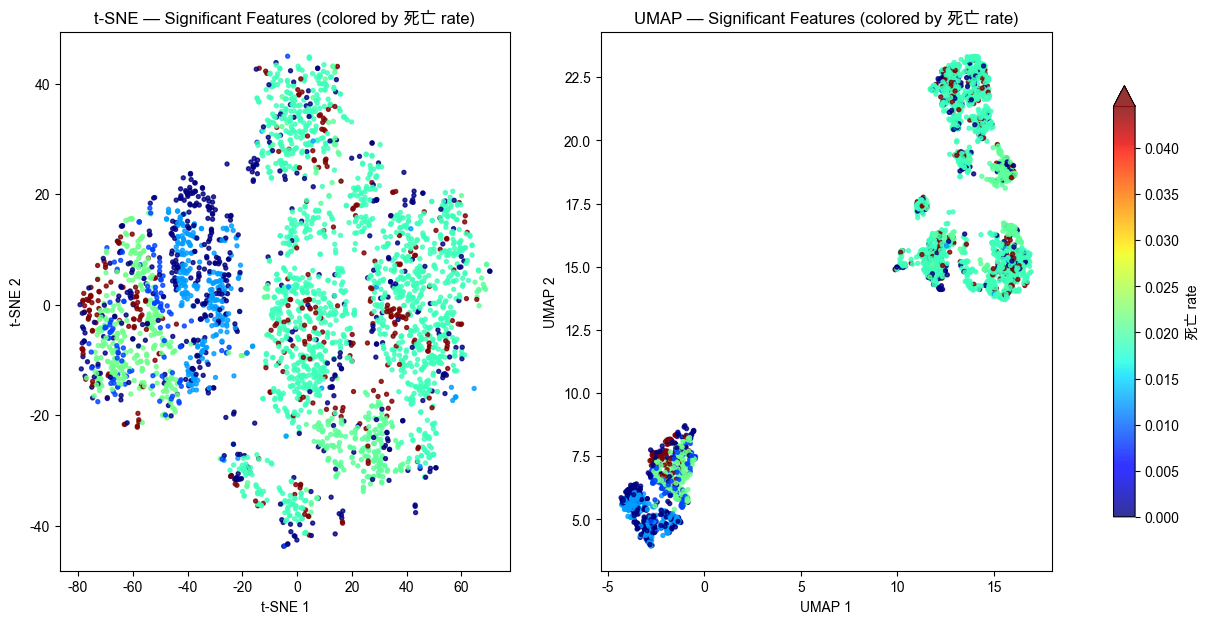

In [10]:
rbind_data['死亡'] = death
plot_embedding_pair_rate(tsne_xy, umap_xy, 'Significant Features', rbind_data, rate_col='死亡')